In [ ]:
import pandas as pd
import seaborn as sns

df = pd.read_csv('malware_dacrank1.csv', index_col=0)
df.head()

Index(['day', 'dac_family', 'qr', 'r', 'nx', 'dn_rank_1', 'wl_rank_le4',
       'u_dac_family', 'u', 'u_wl_rank_le4', 'u_dn_rank_1'],
      dtype='object')


In [120]:

import itertools


day = list(range(10))
dac_families = df.dac_family.drop_duplicates()
cols = ['qr', 'r', 'nx', 'dn_rank_1', 'wl_rank_le4',
       'u_dac_family', 'u', 'u_wl_rank_le4', 'u_dn_rank_1']

values = []
for a, b in itertools.product(day, dac_families):
    values.append([a,b] + [0 for _ in range(len(cols))])

df0 = pd.DataFrame(data=values, columns=df.columns)

# pd.merge(df, right=df0, left_on=['day','dac_family'], right_on=['day','dac_family'], how='left')
DF = pd.concat([df, df0]).drop_duplicates(subset=['day','dac_family']).sort_values(by=['day', 'dac_family'])

In [121]:
from matplotlib import pyplot as plt

cols = ['qr', 'r', 'nx', 'dac_rank_1', 'dac_rank_le2', 'dn_rank_1', 'wl_rank_le4']

DF_ALL = pd.melt(DF, id_vars=['day', 'dac_family'], value_vars=cols, value_name='value')

def draw_heatmap(*args, **kwargs):
    df = kwargs.pop('data')
    sns.heatmap(df.set_index('day')[cols], **kwargs)

fg = sns.FacetGrid(DF, col='dac_family', col_wrap=5, sharex=True, sharey=False)

fg.map_dataframe(draw_heatmap, cbar=False, square = True)
plt.show()

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['dac_rank_1', 'dac_rank_le2']"

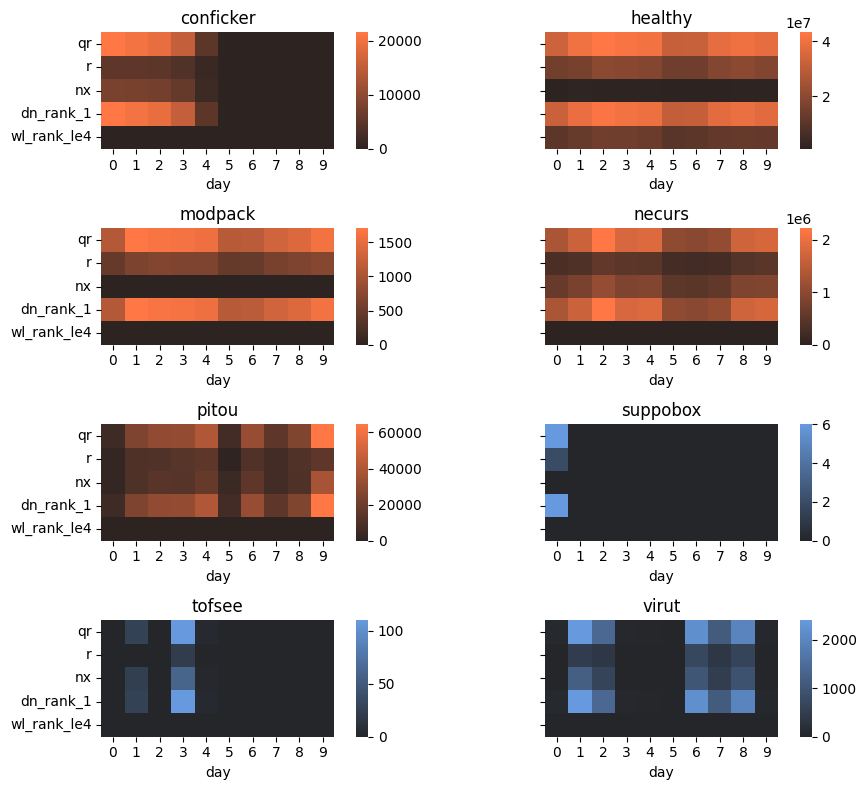

In [126]:
import math
from typing import cast

from matplotlib.axes import Axes
import matplotlib.colors as mcolors

import numpy as np

nrows =4
ncols=2
fig, axs = plt.subplots(nrows, ncols, figsize=(10, 8), sharey=True)
axs = cast(np.ndarray, axs)

cols = ['qr', 'r', 'nx', 'dn_rank_1', 'wl_rank_le4']
for idxmw, mw in enumerate(DF.dac_family.drop_duplicates()):
    row = math.floor(idxmw / ncols)
    col = idxmw % ncols

    DFMW = DF[DF.dac_family == mw].set_index('day')[cols]

    if DFMW['qr'].mean() > 1000:
        cmap = sns.dark_palette("#f74", reverse=False, as_cmap=True)

    else:
        cmap = sns.dark_palette("#69d", reverse=False, as_cmap=True)


    ax = cast(Axes, axs[row, col])

    sns.heatmap(DFMW.T, annot=False, ax=ax, square=True, cbar_kws={'fraction': 0.05, 'aspect':10}, cmap=cmap)
    
    ax.set_title(mw)
    ax.redraw_in_frame()
    pass

# axs[4, 2].axis('off')

fig.tight_layout(h_pad = 1, w_pad=0)

    # im = ax.imshow(DFMW)
    # ax.legend()

    # ax.set_xticks(np.arange(10), labels=map(str, range(10)))
    # ax.set_yticks(np.arange(len(cols)), labels=cols)

    # # Rotate the tick labels and set their alignment.
    # plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
    #         rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    # for i in range(10):
    #     for j, col in enumerate(cols):
    #         text = ax.text(j, i, DFMW.at[i, col], ha="center", va="center", color="w")